# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [27]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split

In [20]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [5]:
RAW_DIR = Path("../dataset_5_class_animal_raw")

print(RAW_DIR.resolve())

/mnt/d/AWS AI/4. Membangun Sistem ML/Eksperimen_SML_Khairul-Rasyid/dataset_5_class_animal_raw


In [28]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

data = []

for class_dir in sorted(RAW_DIR.iterdir()):
    if not class_dir.is_dir():
        continue

    label = class_dir.name

    for image_path in class_dir.rglob("*"):
        if image_path.suffix.lower() in IMAGE_EXTENSIONS:
            data.append({
                "filepath": str(image_path),
                "label": label
            })

df = pd.DataFrame(data)

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

##### Menampilkan 5 data gambar pertama

In [29]:
df.head()

,filepath,label
0,../dataset_5_class_animal_raw/cat/cat (1).jpeg,cat
1,../dataset_5_class_animal_raw/cat/cat (1).jpg,cat
2,../dataset_5_class_animal_raw/cat/cat (10).jpeg,cat
3,../dataset_5_class_animal_raw/cat/cat (10).jpg,cat
4,../dataset_5_class_animal_raw/cat/cat (100).jpeg,cat


##### Jumlah Gambar dan Jumlah Kelas

In [30]:
print("Jumlah gambar:", len(df))
print("Jumlah kelas:", df["label"].nunique())

Jumlah gambar: 12857
Jumlah kelas: 5


##### Nama Setiap Kelas

In [31]:
print(df["label"].unique())

<StringArray>
['cat', 'cow', 'dog', 'elephant', 'horse']
Length: 5, dtype: str


##### Distribusi Gambar Pada Setiap Kelas

In [32]:
df["label"].value_counts()

label
horse       2680
cow         2586
elephant    2548
cat         2529
dog         2514
Name: count, dtype: int64

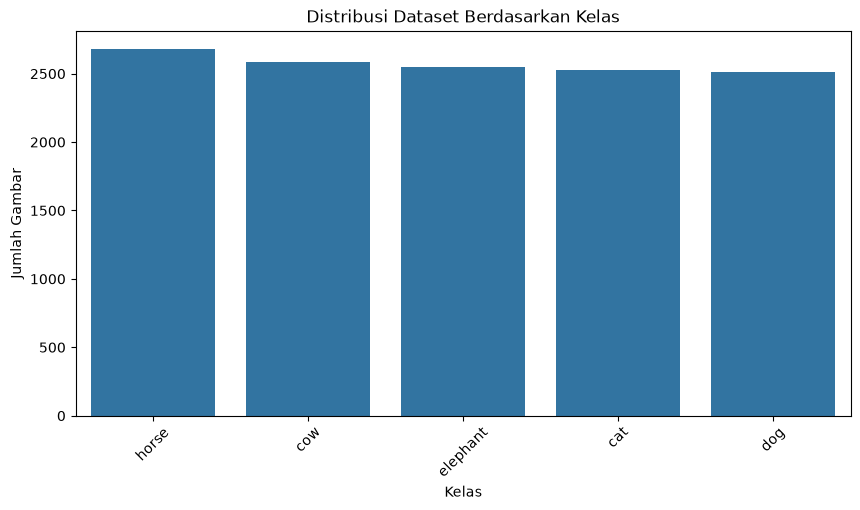

In [10]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="label",
    order=df["label"].value_counts().index
)

plt.title("Distribusi Dataset Berdasarkan Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=45)
plt.show()

##### Contoh Gambar Pada Masing-Masing Kelas

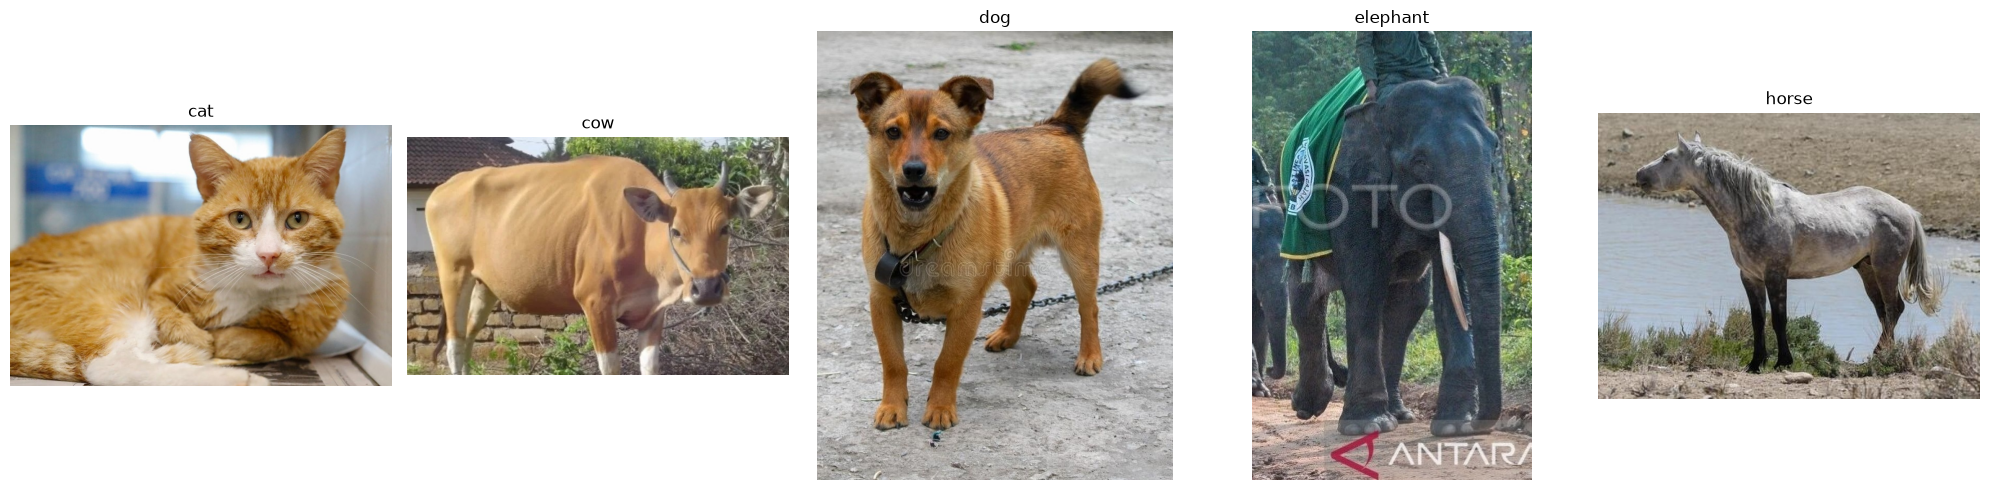

In [13]:
classes = sorted(df["label"].unique())

fig, axes = plt.subplots(
    1,
    min(len(classes), 5),
    figsize=(20, 5)
)

for ax, class_name in zip(axes, classes[:5]):
    sample = df[df["label"] == class_name].sample(
        1,
        random_state=SEED
    ).iloc[0]

    image = Image.open(sample["filepath"])

    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

##### Ukuran Gambar

In [14]:
image_sizes = []

for path in df["filepath"]:
    try:
        with Image.open(path) as img:
            image_sizes.append(img.size)
    except:
        image_sizes.append(None)

df["image_size"] = image_sizes

In [15]:
df["image_size"].value_counts().head(20)

image_size
(678, 452)      31
(390, 280)      25
(738, 414)      23
(547, 365)      23
(500, 333)      17
(638, 480)      16
(554, 554)      16
(447, 447)      15
(654, 468)      12
(500, 375)      11
(515, 388)      11
(597, 335)      10
(2500, 2500)    10
(500, 500)      10
(389, 280)       9
(600, 504)       9
(335, 597)       8
(400, 400)       8
(480, 640)       8
(387, 516)       8
Name: count, dtype: int64

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

##### Mencari Gambar Korup/Rusak

In [33]:
def check_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except:
        return False

In [34]:
df["is_valid"] = df["filepath"].apply(check_image)

df["is_valid"].value_counts()

is_valid
True    12857
Name: count, dtype: int64

##### Split Dataset

In [35]:
df_clean = df[df["is_valid"]].copy()

df_clean = df_clean.drop(columns=["is_valid"])

In [21]:
train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.20,
    stratify=df_clean["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

In [22]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 10285
Validation: 1286
Test: 1286


In [23]:
print("TRAIN")
print(train_df["label"].value_counts())

print("\nVALIDATION")
print(val_df["label"].value_counts())

print("\nTEST")
print(test_df["label"].value_counts())

TRAIN
label
horse       2144
cow         2069
elephant    2038
cat         2023
dog         2011
Name: count, dtype: int64

VALIDATION
label
horse       268
cow         258
elephant    255
cat         253
dog         252
Name: count, dtype: int64

TEST
label
horse       268
cow         259
elephant    255
cat         253
dog         251
Name: count, dtype: int64


In [36]:
OUTPUT_DIR = Path("./dataset_5_class_animal_preprocessing")

splits = {
    "train": train_df,
    "validation": val_df,
    "test": test_df
}

In [37]:
for split_name, split_df in splits.items():

    for _, row in split_df.iterrows():

        source = Path(row["filepath"])
        label = row["label"]

        destination_dir = (
            OUTPUT_DIR /
            split_name /
            label
        )

        destination_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        destination = destination_dir / source.name

        with Image.open(source) as image:
            image = image.convert("RGB")
            image = image.resize((224, 224))

            image.save(destination)